In [1]:
import numpy as np                                                                                                                                                          
import matplotlib.pyplot as plt                                                                                                                                             
import sys                                                                                                                                                                  
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work')                                                                                                           
                                                                                                                                                                            
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                  
# from inference import build_waveform_response
# from stableemrifisher.utils import generate_PSD                                                                                                                             
# from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens                                                                                          
# from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux
# from fastlisaresponse import ResponseWrapper
# from lisatools.detector import EqualArmlengthOrbits
import cupy as cp 

try:                                                                                                                                                                        
    import cupy as cp                                                                                                                                                       
    xp = cp                                                                                                                                                                 
    use_gpu = True                                                                                                                                                          
except ImportError:                                                                                                                                                         
    xp = np     
    use_gpu = False      

# xp=np
# use_gpu=False

force_backend = "cuda12x"
# NOTE: prolly dont need this
# inspiral_kwargs={
#         "func": 'KerrEccEqFlux',
#         "DENSE_STEPPING": 0,
#         "include_minus_m": False,
# }

# amplitude_kwargs = {
#     "force_backend": force_backend
# }

# Ylm_kwargs = {
#     "force_backend": force_backend,
# }

# sum_kwargs_comb = {
#     "force_backend": force_backend,
#     "pad_output": True,
# }

# sum_kwargs_sep = {
#     "force_backend": force_backend,
#     "pad_output": True,
#     "separate_modes": True,
# }                                                                                                                                                   


In [2]:
                                                                                                                                       
T = 3/12        # years                 
dt = 10.0       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 1.8  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=2)                                                                                                    
         

In [3]:
# generate signal       
wave_params = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,                                                                                                            
                Phi_phi0, Phi_theta0, Phi_r0]                                                                                  
# emri_kwargs = {"T": T, "dt": dt}                                                                                                                              
                                                                                                                                                                            
signal = xp.array(waveform_response(*wave_params, T=T, dt=dt))
print("signal shape:", signal.shape)                                                                                                                                        
                           

signal shape: (3, 788953)


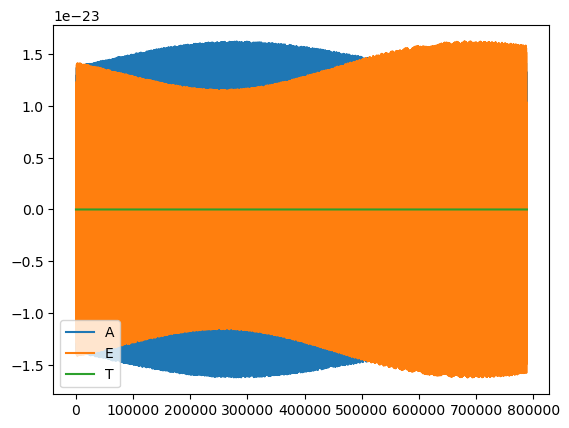

In [4]:
plt.plot(signal[0].get(),label='A')
plt.plot(signal[1].get(),label='E')
plt.plot(signal[2].get(),label='T')
plt.legend()
plt.show()

In [5]:
# build gwf class                                                                                                                                                     
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=2)


In [6]:
# check inner prod and snr of signal 

signal_f = gwf.freq_wave(signal)                                                                                                                                            
inner_signal = xp.asarray(gwf.inner(signal_f, signal_f))
print('inner: ', inner_signal.get())
snr = xp.sqrt(inner_signal)
print('snr: ', snr.get())


inner:  5326333.702506639
snr:  2307.885114668111


/scratch/e1498138/anaconda3/envs/fewsm/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/scratch/e1498138/anaconda3/envs/fewsm/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


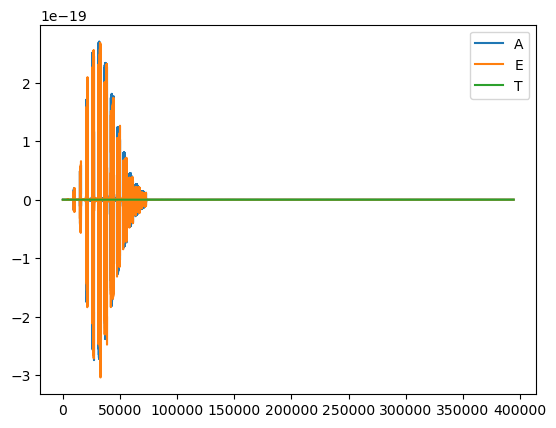

In [7]:
plt.plot(signal_f[0].get(),label='A')
plt.plot(signal_f[1].get(),label='E')
plt.plot(signal_f[2].get(),label='T')
plt.legend()
plt.show()

In [8]:
gwf.N

788953

In [9]:
df=1/(gwf.N*gwf.dt)

In [10]:
sens=gwf.PSD.get()   
sens                                                                                                                                                                   

array([[3.00697129e-45, 3.00697226e-45, 3.00697387e-45, ...,
        4.81942419e-40, 4.81924986e-40, 4.81907553e-40],
       [3.00697129e-45, 3.00697226e-45, 3.00697387e-45, ...,
        4.81942419e-40, 4.81924986e-40, 4.81907553e-40],
       [3.00329760e-64, 4.80527616e-63, 2.43267106e-62, ...,
        1.60157982e-39, 1.60152916e-39, 1.60147850e-39]],
      shape=(3, 394476))

In [11]:
signal_f_a=signal_f.get()[0,1:]
integrand_a=4*df*np.abs(signal_f_a)**2 / sens[0]
integrand_a

array([1.56215330e-06, 1.56242734e-06, 1.56288404e-06, ...,
       2.76192823e-13, 2.76202498e-13, 2.76212110e-13], shape=(394476,))

In [12]:
sens[0]

array([3.00697129e-45, 3.00697226e-45, 3.00697387e-45, ...,
       4.81942419e-40, 4.81924986e-40, 4.81907553e-40], shape=(394476,))

In [13]:
signal_f_a

array([9.62489319e-23-1.05560058e-24j, 9.62400257e-23-2.11113552e-24j,
       9.62251845e-23-3.16653799e-24j, ...,
       1.61999169e-23+3.23463833e-25j, 1.62019741e-23+1.94088186e-25j,
       1.62029963e-23+6.46966562e-26j], shape=(394476,))

In [14]:
np.cumsum(integrand_a)[-1]

np.float64(398.81155963512947)

In [15]:
signal_f_e=signal_f.get()[1,1:]
integrand_e=4*df*np.abs(signal_f_e)**2 / sens[1]
integrand_e
np.cumsum(integrand_e)[-1]

np.float64(355.56071172679316)

In [16]:
sens[1]

array([3.00697129e-45, 3.00697226e-45, 3.00697387e-45, ...,
       4.81942419e-40, 4.81924986e-40, 4.81907553e-40], shape=(394476,))

In [17]:
signal_f_e

array([-1.97269637e-22+1.51407626e-24j, -1.97250739e-22+3.02805537e-24j,
       -1.97219244e-22+4.54184349e-24j, ...,
        2.38981206e-23+4.96929475e-25j,  2.39011450e-23+2.98166891e-25j,
        2.39026639e-23+9.93887092e-26j], shape=(394476,))

In [18]:
signal_f_t=signal_f.get()[2,1:]
integrand_t=4*df*np.abs(signal_f_t)**2 / sens[2]
integrand_t
np.cumsum(integrand_t)[-1]

np.float64(5325579.330233345)

In [19]:
sens[2] #NOTE: way smaller sensitivity for T channel

array([3.00329760e-64, 4.80527616e-63, 2.43267106e-62, ...,
       1.60157982e-39, 1.60152916e-39, 1.60147850e-39], shape=(394476,))

In [20]:
signal_f_t

array([5.39869432e-26-3.94988769e-28j, 5.39825874e-26-7.89376292e-28j,
       5.39735937e-26-1.18398298e-27j, ...,
       1.46187021e-27-1.04431640e-29j, 1.46166664e-27-9.05309375e-30j,
       1.46442373e-27-6.67970630e-32j], shape=(394476,))

In [21]:
n_realizations = 1000                                                                                                                                                      
inner_products = [] 
noise_realizations = []   
seed=42 
rng=np.random.default_rng(seed)
seed_array = rng.integers(0,int(1e6),size=1000)                                                                                                                                                                                                                                                                                                                                             


In [22]:
for i in range(n_realizations):                                                                                                                                             
    noise_td = gwf.generate_colored_noise(seed=seed_array[i]) 
    noise_realizations.append(noise_td)                                                                                                                                                                                                                                                                                                       
    noise_f = gwf.freq_wave(noise_td)                                                                                                                                       
    ip = xp.asarray(gwf.inner(noise_f, signal_f))
    inner_products.append(ip)

In [23]:
ip_arr = xp.array(inner_products)
mean_ip = xp.mean(ip_arr)
print('Expectation val: ', mean_ip.get())
#NOTE: should be ~0

Expectation val:  -81.61233555374889


In [24]:
ip_arr

array([-6.47100712e+02, -7.66509133e+02,  2.19092670e+03,  2.60225798e+03,
        2.72474421e+03,  1.18794127e+02, -4.41895510e+01,  3.49264250e+02,
       -4.78996808e+02,  3.36227041e+03, -5.68342382e+02, -6.23040332e+02,
        6.08904049e+03, -2.67098975e+03, -2.84789254e+03,  1.32482235e+03,
       -1.56823156e+03, -1.87753269e+03,  3.41686135e+03,  6.23368451e+02,
        2.20452490e+03,  5.78231524e+03,  4.37710040e+03, -9.49424206e+02,
        2.69114796e+03,  1.15957153e+03,  2.31526616e+03, -4.69480824e+03,
        2.71039446e+02,  7.12800867e+02,  1.18962732e+03,  1.70842297e+03,
       -1.48739602e+02, -2.05855971e+03,  1.92183929e+02, -5.07482329e+03,
       -1.00958213e+03,  5.03614688e+02,  1.58133745e+03, -1.02177060e+03,
       -3.24441230e+03, -3.63838793e+03, -9.97303781e+02,  7.31510774e+01,
       -1.25053978e+03,  1.61322081e+03, -3.30013382e+02, -6.98812433e+02,
        1.09807692e+03,  4.06467025e+02,  1.72526040e+03, -1.25937125e+03,
       -5.14617774e+03, -

In [25]:
var_ip = xp.var(ip_arr)
print('Var: ', var_ip.get())

Var:  5222075.719935946


In [26]:
ratio = var_ip/inner_signal
print('Ratio:', ratio.get())

Ratio: 0.9804259386674125


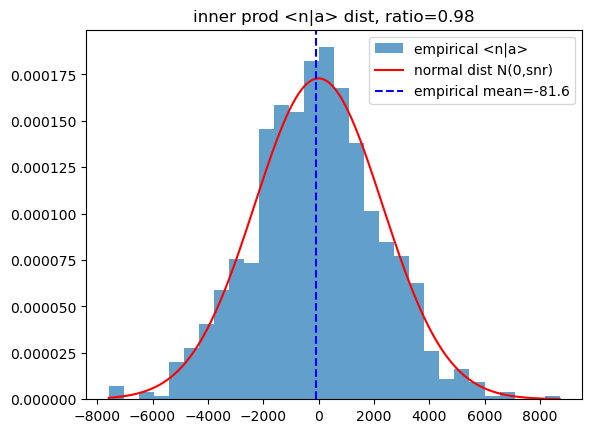

In [27]:
                                                                                                                                                                     
# mean plot                 
# # the expected std is the snr
snr_np = snr.get()                                                                                                                                          
x = np.linspace(ip_arr.get().min(), ip_arr.get().max(), 300)
gaussian = np.exp(-0.5*(x/snr_np)**2)/(snr_np*np.sqrt(2*np.pi))

plt.hist(ip_arr.get(), bins=30, density=True, alpha=0.7, label="empirical <n|a>")
plt.plot(x, gaussian, 'r-', label=f"normal dist N(0,snr)")                                                                      
plt.axvline(mean_ip.get(), color='blue', linestyle='--', label=f"empirical mean={mean_ip.get():.3g}")
plt.title(f"inner prod <n|a> dist, ratio={ratio.get():.3g}")                                                                                                                 
plt.legend()  
plt.show()                      
                                                                                                                                                                         

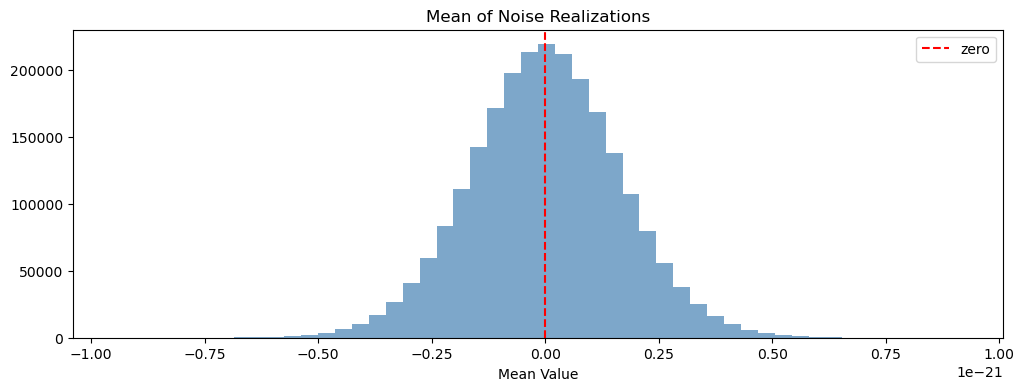

In [28]:
fig, axes = plt.subplots(figsize=(12, 4))
noise_realizations = xp.stack(noise_realizations)
mean_noise = noise_realizations.mean(axis=0).get()
plt.hist(mean_noise.flatten(), bins=50, alpha=0.7, color="steelblue")                                                                                                                                                
plt.axvline(0, color="red", linestyle="--", label="zero")                                                                                                                                                            
plt.title("Mean of Noise Realizations")
plt.xlabel("Mean Value")
plt.legend()
plt.show()                                                                                                                                                          


In [29]:
print(mean_noise)

[[-2.89159517e-23  1.35211181e-22 -5.26664045e-23 ...  8.90199000e-23
  -9.72256906e-23  4.18169746e-23]
 [-1.73658576e-23 -3.19139668e-23  2.47396022e-22 ...  2.39317945e-22
  -3.12936261e-22  8.72518014e-23]
 [ 2.29078249e-22 -8.75493163e-23 -1.07183677e-22 ...  4.18255253e-23
   3.85959862e-23 -2.24342013e-22]]


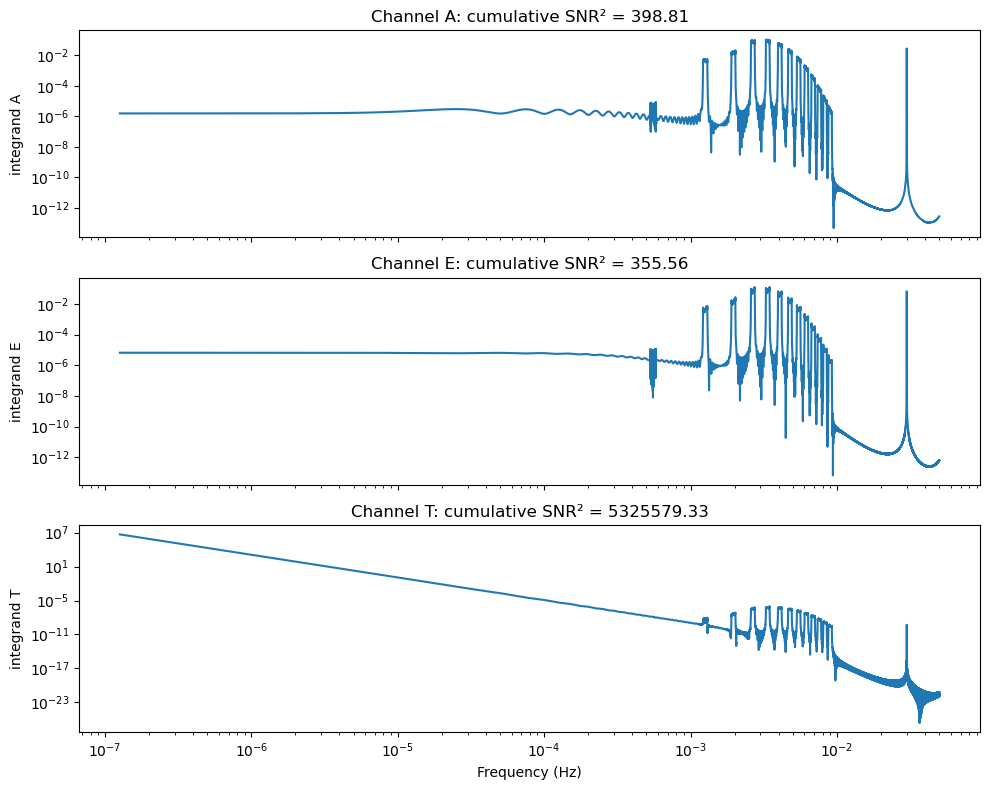

In [30]:
                                                                                                                                                                                         
df = 1 / (gwf.N * gwf.dt)                                                                                                                                                                                           
freqs = np.fft.rfftfreq(gwf.N, gwf.dt)[1:]  # drop DC
                                                                                                                                                                                                                                                                                                                                                                       
sens=gwf.PSD.get()                                                                                                                                                                        
                                                                                                                                                                                                                    
channel_names = ['A', 'E', 'T']         
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)                                                                                                                                                        
                                                                                                                                                                                                                    
for i, ax in enumerate(axes):
    Hf = signal_f.get()[i, 1:]          # drop DC, shape (N//2,)                                                                                                                                                       
    integrand = 4 * df * np.abs(Hf)**2 / sens[i]                                                                                                                                                                  
    ax.loglog(freqs, integrand)
    ax.set_ylabel(f'integrand {channel_names[i]}')                                                                                                                                                                  
    ax.set_title(f'Channel {channel_names[i]}: cumulative SNR² = {np.cumsum(integrand)[-1]:.2f}')                                                                                                                   
                                                                                                                                                                                                                    
axes[-1].set_xlabel('Frequency (Hz)')                                                                                                                                                                               
plt.tight_layout()                                                                                                                                                                                                  
plt.show()                                                                                                                                                                                                          
                                        
